In [1]:
import seaborn as sns
import plotly.express as px

In [2]:
# import datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

### Categorical plots

Categorical scatter plot 
 - stripplot
 - swarmplot
  
Categorical distribution plots
 - Boxplot
 - Violinplot

Categorical Estimate Plot -> for central tendency
 - Barplot
 - Pointplot
 - countplot

Figure level function -> `catplot`

<Axes: xlabel='total_bill', ylabel='tip'>

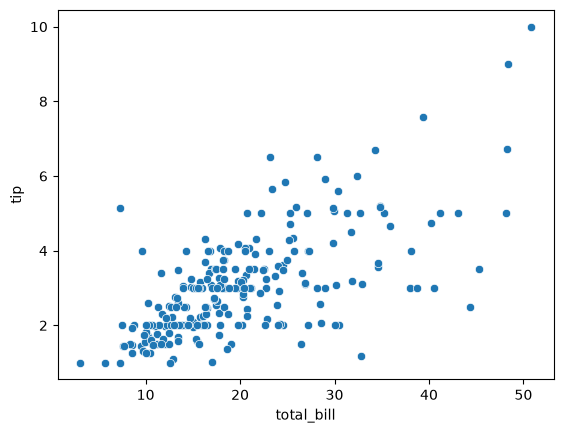

In [4]:
sns.scatterplot(data=tips , x='total_bill' , y='tip')

<Axes: xlabel='day', ylabel='total_bill'>

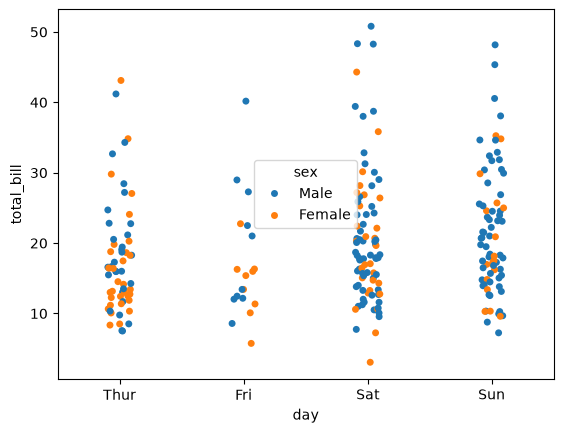

In [6]:
#strip plot 
#axes level function
sns.stripplot(data=tips , x='day' , y='total_bill', hue='sex')

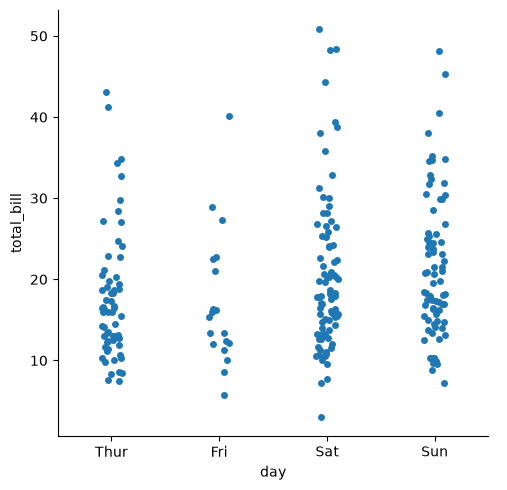

In [7]:
#using catplot 
#figure level function
sns.catplot(data=tips , x='day' , y='total_bill' , kind='strip')

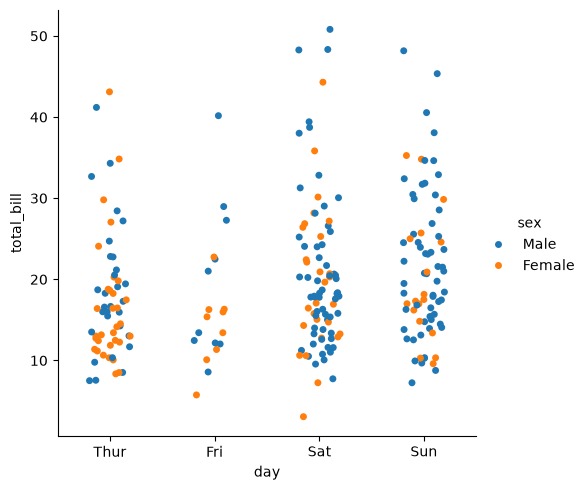

In [13]:
#jitter
sns.catplot(data=tips , x='day', y='total_bill' , kind='strip' , jitter=0.2 , hue='sex')

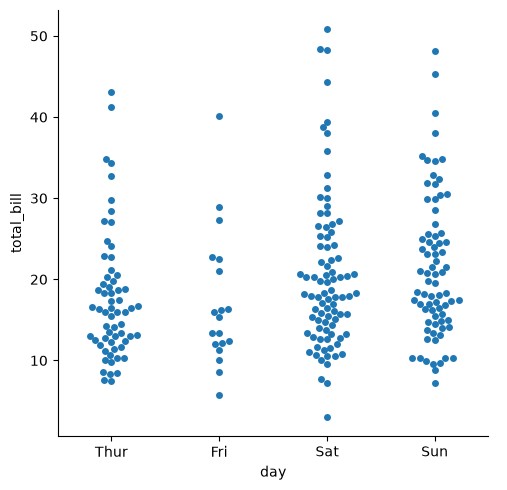

In [14]:
#swarmplot
sns.catplot(data=tips,x='day' , y='total_bill' , kind='swarm')

<Axes: xlabel='day', ylabel='total_bill'>

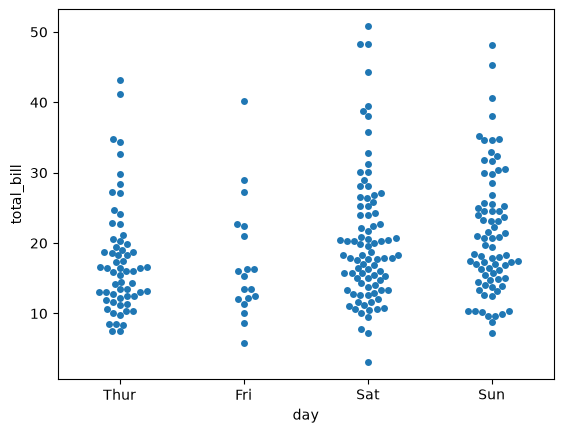

In [15]:
sns.swarmplot(data=tips , x='day' , y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

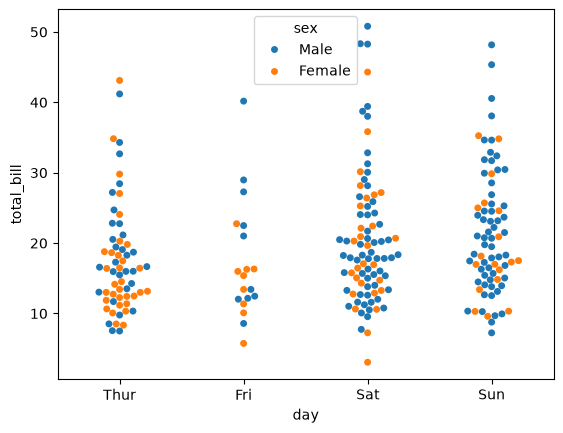

In [16]:
#hue 
sns.swarmplot(data=tips , x='day' , y='total_bill' , hue='sex')

### Boxplot

A boxplot is a standardized way of displaying the distribution of data based on a five number summary (`"minimum" , first quartile [Q1] , median , third quartile [Q3] and "maximum"`). It can tell you about your outliers and what their values are. Boxplots can also tell you if your data is symmetrical , how tightly your data is grouped and if and how your data is skewed.

<Axes: xlabel='day', ylabel='total_bill'>

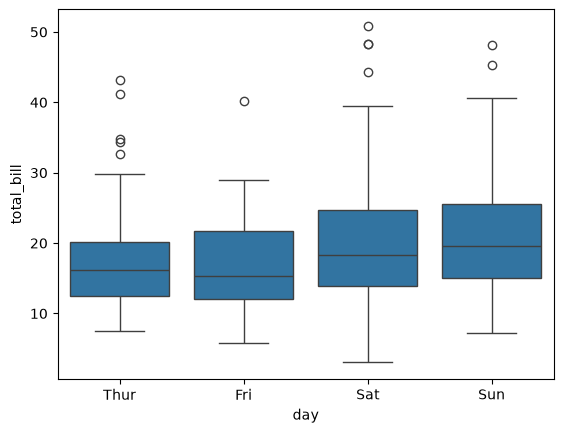

In [17]:
# box plot 
sns.boxplot(data=tips , x='day' , y='total_bill')

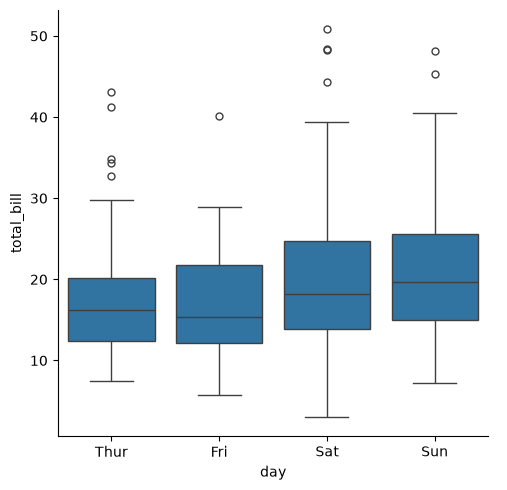

In [18]:
# using catplot 
sns.catplot(data=tips , x='day' , y='total_bill' , kind='box')

<Axes: xlabel='day', ylabel='total_bill'>

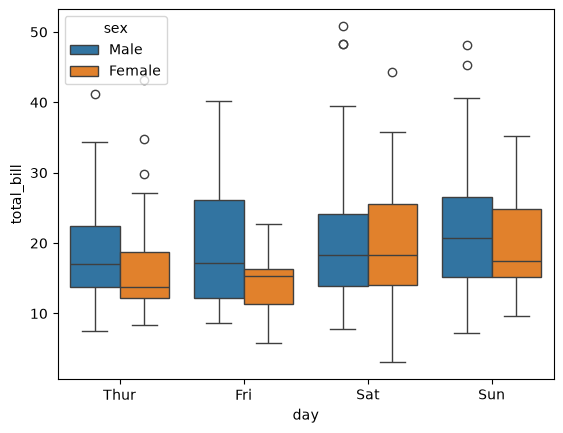

In [19]:
# hue
sns.boxplot(data=tips , x='day' , y='total_bill' , hue='sex')

<Axes: ylabel='total_bill'>

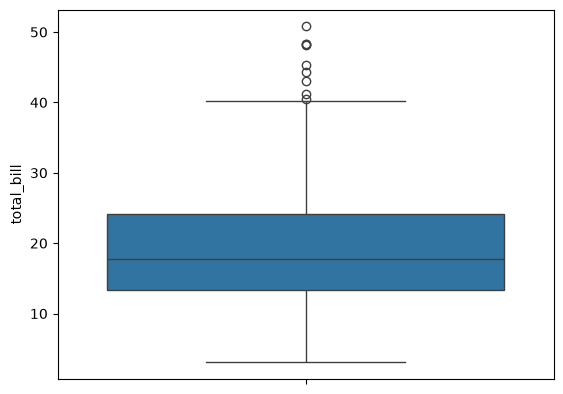

In [20]:
# single boxplot -> numerical col
sns.boxplot( data=tips , y='total_bill' )

### Violinplot = (Boxplot + KDEplot)

<Axes: xlabel='day', ylabel='total_bill'>

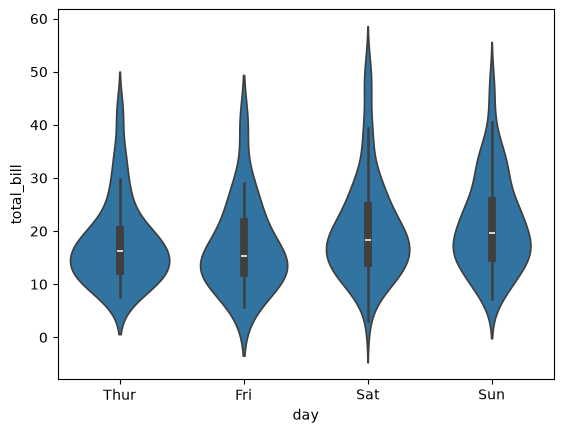

In [21]:
# violonplot 
sns.violinplot(data=tips , x='day' , y='total_bill')

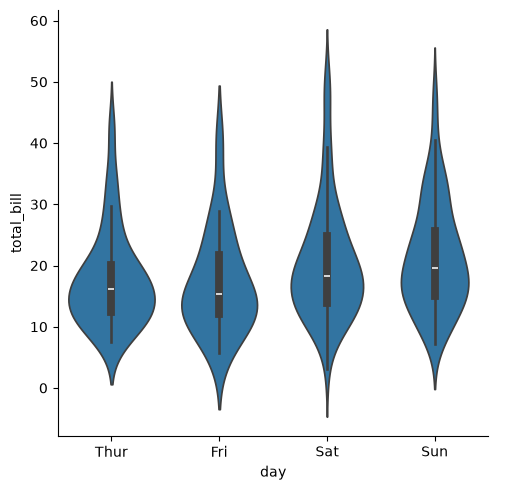

In [22]:
sns.catplot(data=tips , x='day' , y='total_bill' , kind='violin')

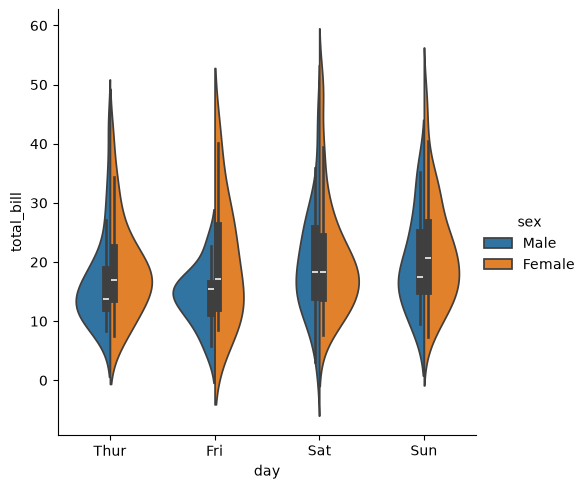

In [26]:
# hue
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',hue='sex',split=True)

<Axes: xlabel='sex', ylabel='total_bill'>

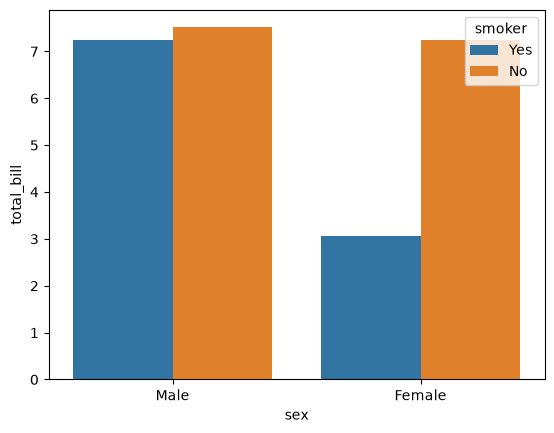

In [ ]:
#barplot ( sns.barplot() plots the mean (average) by default )
#some issue with errorbar
# estimator default is mean
import numpy as np
sns.barplot(data=tips , x='sex' , y='total_bill' , hue='smoker' , estimator=np.min , errorbar=None)

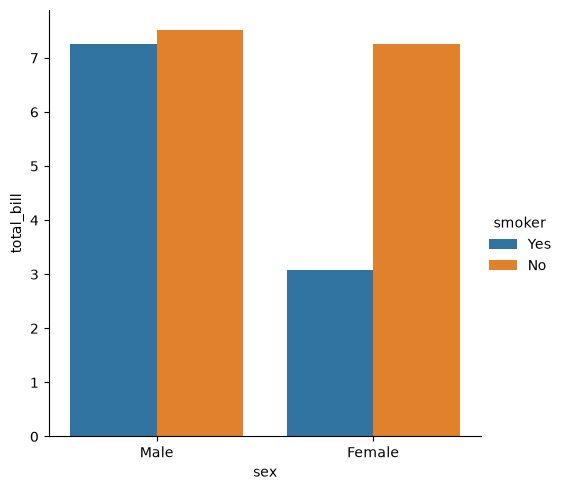

In [28]:
sns.catplot(data=tips , kind='bar' , x='sex' , y='total_bill' , hue='smoker' , estimator=np.min , errorbar=None)

<Axes: xlabel='sex', ylabel='total_bill'>

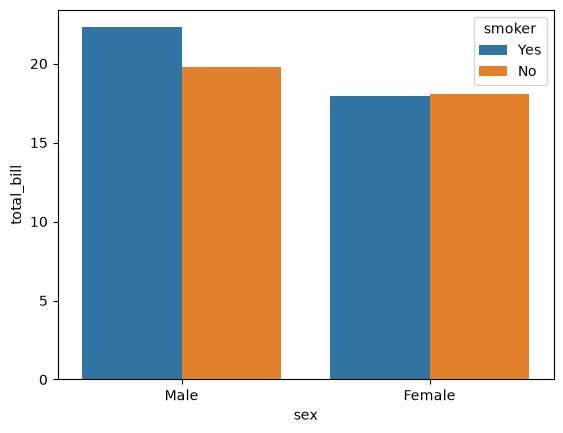

In [32]:
sns.barplot(data=tips , x='sex' , y='total_bill' , hue='smoker' , errorbar=None)

<Axes: xlabel='sex', ylabel='total_bill'>

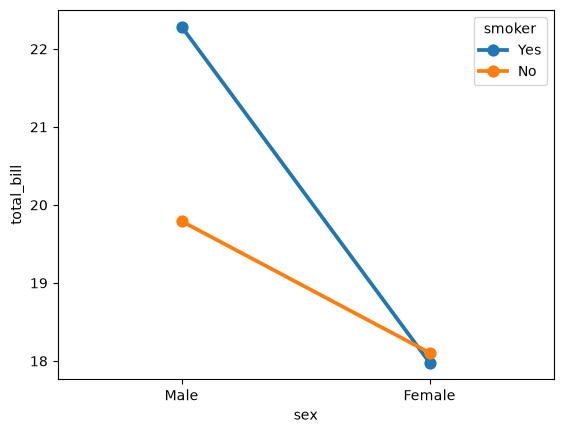

In [31]:
# Point plot
sns.pointplot(data=tips , x='sex' , y='total_bill' , hue='smoker' , errorbar=None)

When there are multiple observations in each category , it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars

<Axes: xlabel='sex', ylabel='count'>

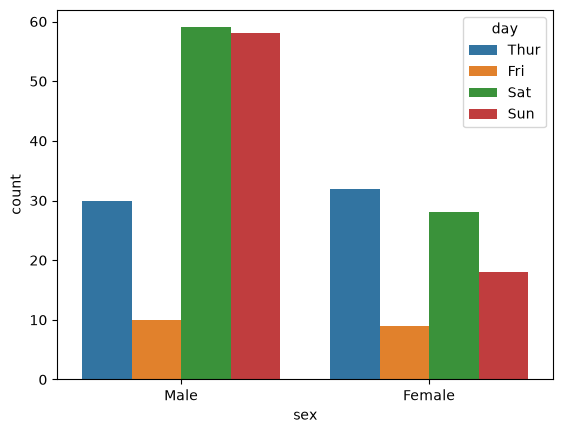

In [33]:
# countplot
sns.countplot(data=tips , x='sex' , hue='day')

A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical , rather than quantitative varible 

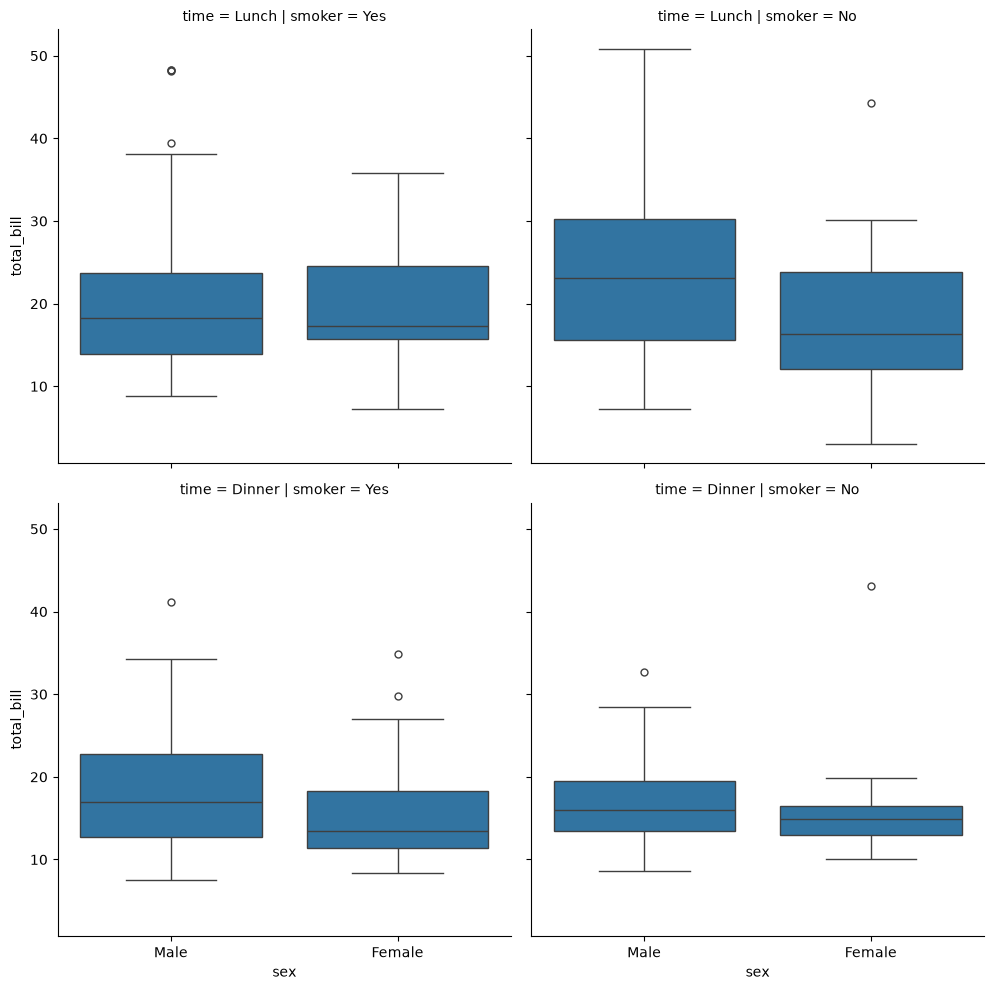

In [34]:
# faceting using catplot
sns.catplot(data=tips , x='sex' , y='total_bill' , kind='box' ,col='smoker' , row='time')

### Regression Plot
  - regplot
  - Lmplot

In the simplest invocation , both functions draw a scatterplot of two variables , x and y , and then fit the regression model y ~ x and plot the resulting regression line and a 95% confidence interval for that regression

<Axes: xlabel='total_bill', ylabel='tip'>

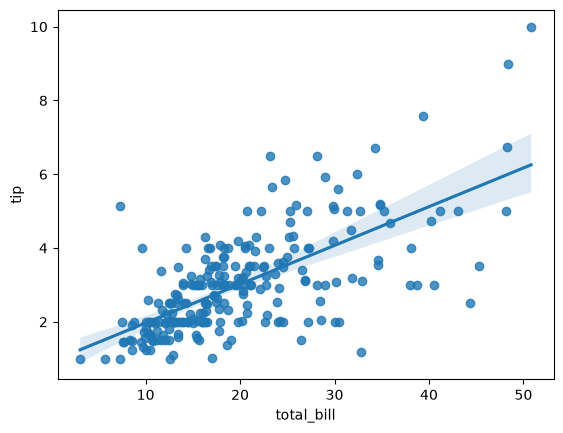

In [35]:
# axes level
# hue parameter is not available
sns.regplot(data=tips , x='total_bill' , y='tip')

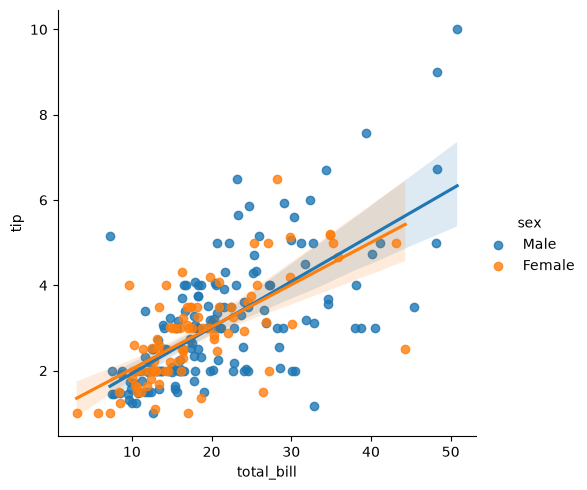

In [ ]:
sns.lmplot(data=tips , x='total_bill' , y='tip' , hue='sex')
#only lmplot allow hue not regplot

### Plotting Pairwise relationship ( PairGrid VS Pairplot)

for numerical cols

In [38]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


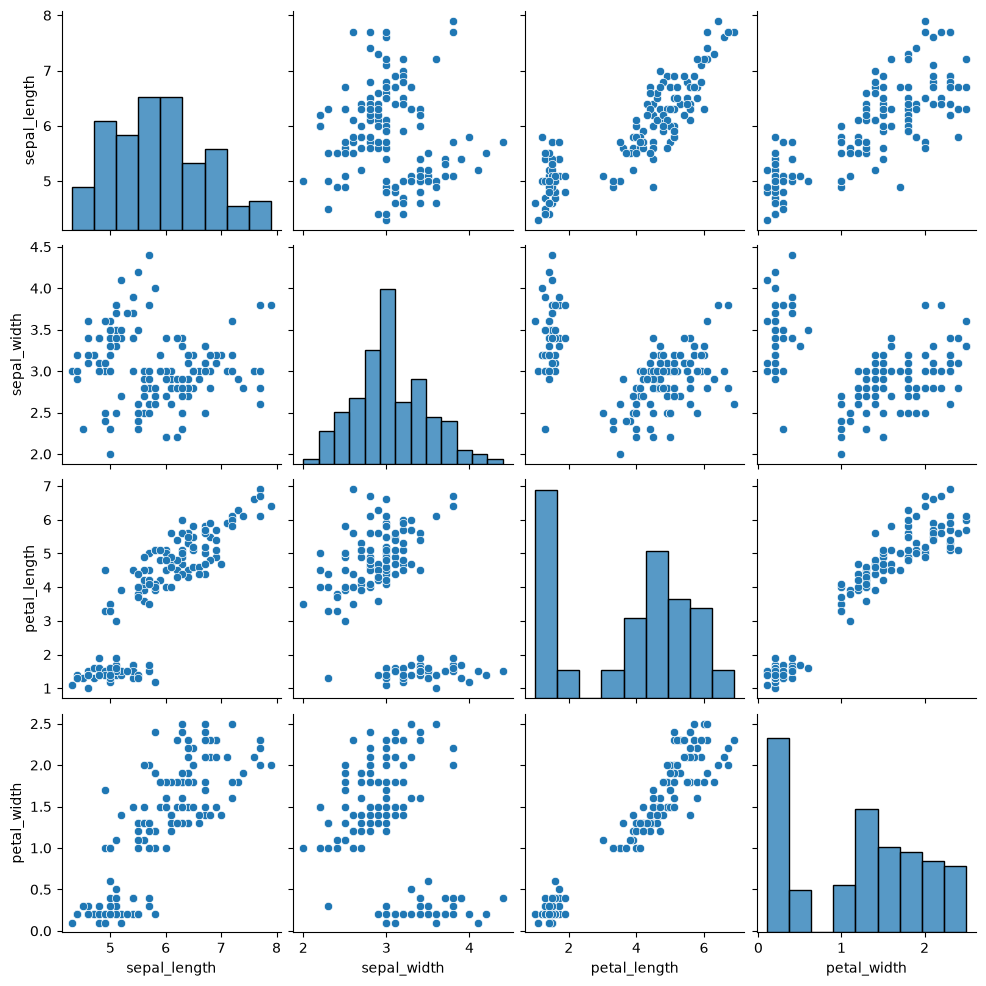

In [ ]:
sns.pairplot(iris)
# automatically make pairs between numerical columns

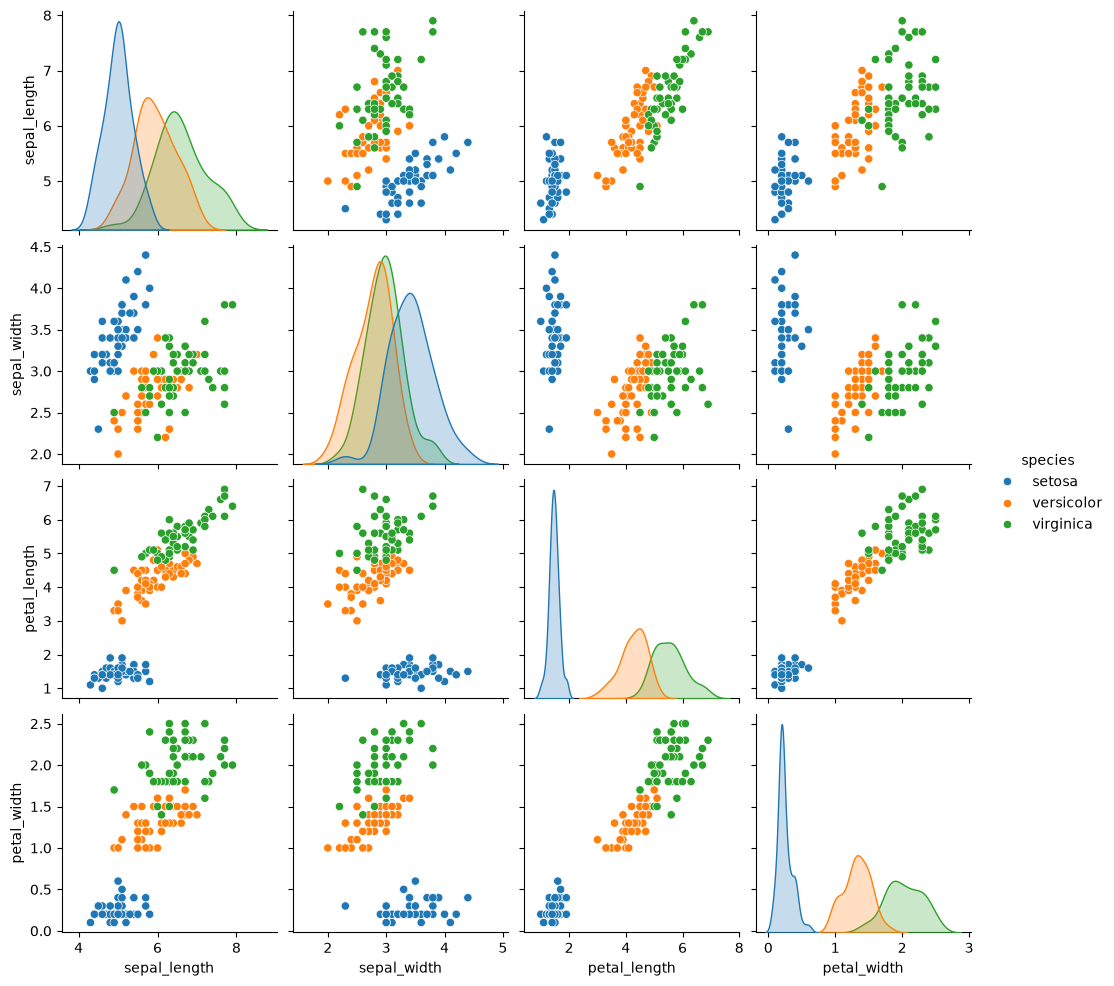

In [40]:
sns.pairplot(iris , hue='species')

### Pairplot - is a special case of pairgrid
### PairGrid - is a general form with more functioning

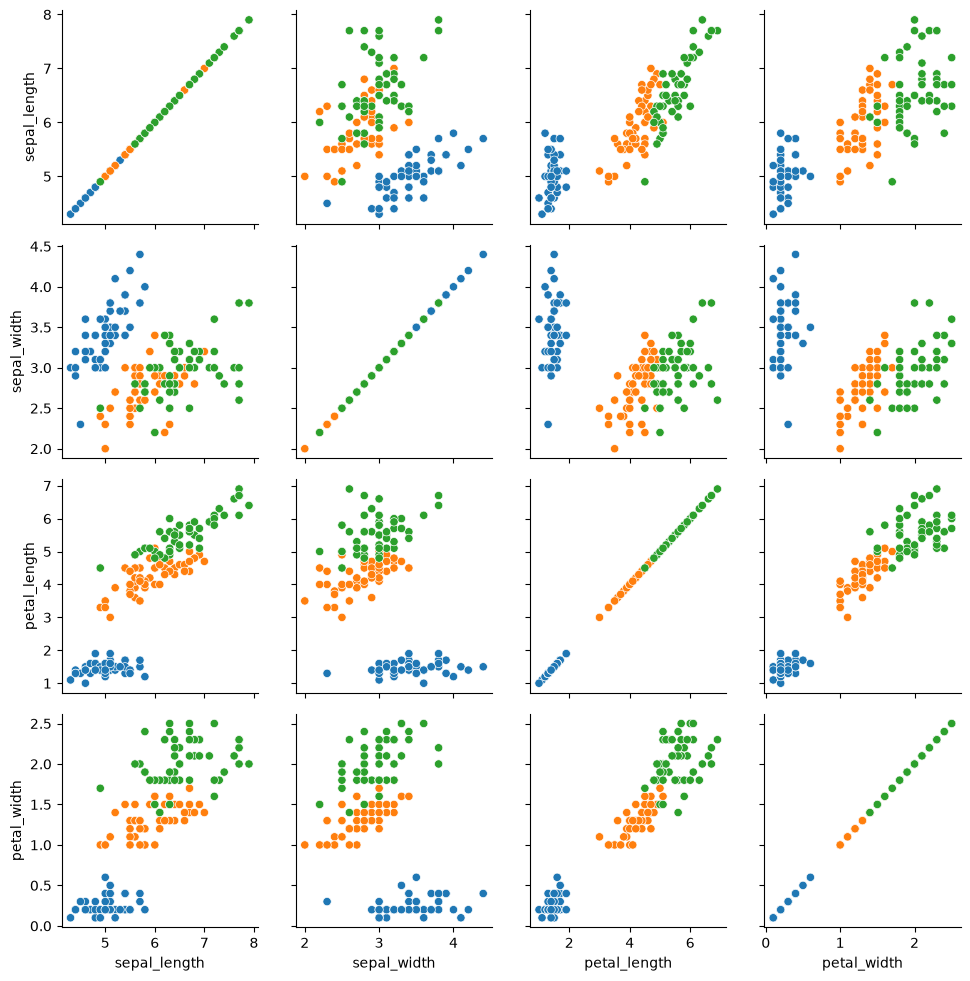

In [41]:
# pair grid
g = sns.PairGrid(data=iris , hue='species')

# g.map
g.map(sns.scatterplot)

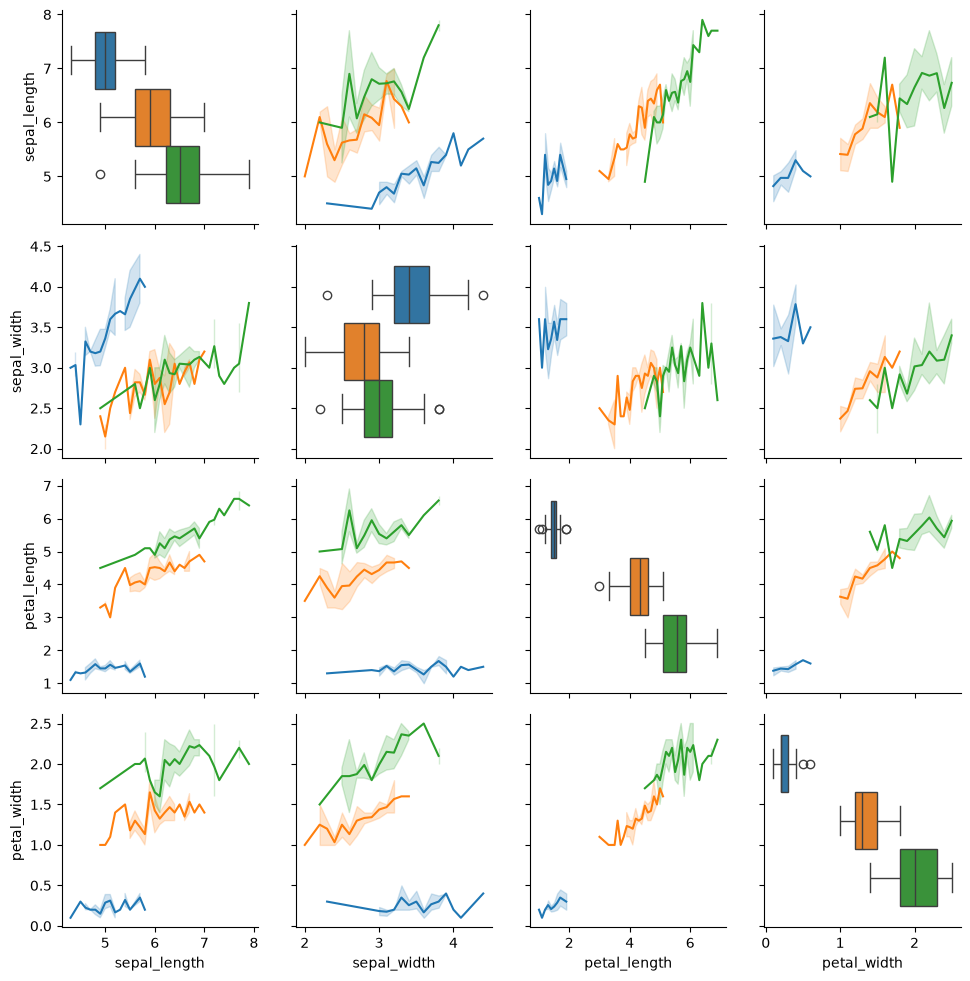

In [43]:
# map_diag() is for diagonal ele
# map_offdiag is for except diag

g = sns.PairGrid(data=iris , hue='species')
g.map_diag(sns.boxplot)
g.map_offdiag(sns.lineplot)

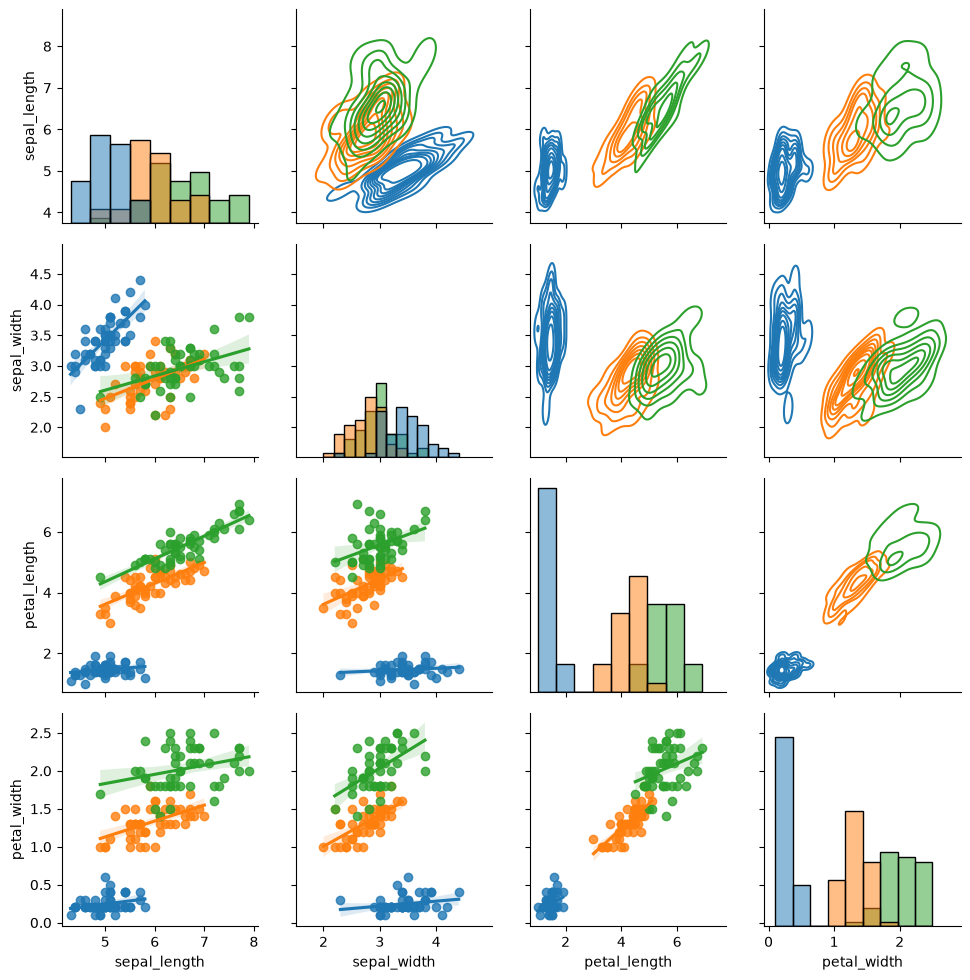

In [45]:
# we can also set upper diag and lower diag differently
g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.regplot)

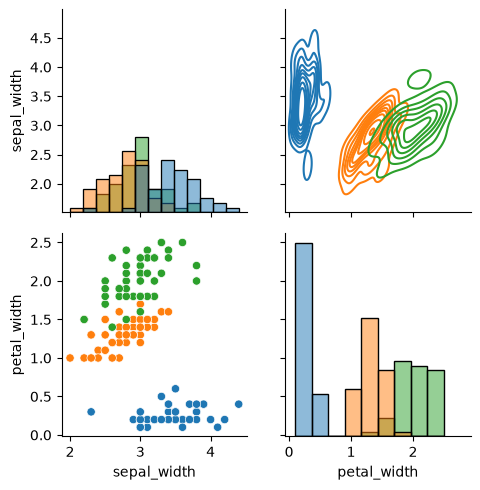

In [46]:
# we can also set which cols we want to plot in graph

# vars
g = sns.PairGrid(data=iris,hue='species',vars=['sepal_width','petal_width'])
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)

### Some utility functions

In [47]:
# get dataset names
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [48]:
# load dataset
sns.load_dataset('flights')

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


### -----------------------------END-------------------------------